<a href="https://colab.research.google.com/github/Himani585/Celebal-techonology/blob/main/Week_6_Himani_Gupta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [14]:
# Load and Prepare Data
# ------------------------------------
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]


In [15]:
# Noise Generator
# ------------------------------------
def add_gaussian_noise(data, std=0.35):
    random_noise = np.random.normal(0, std, data.shape)
    noisy_data = data + random_noise
    return np.clip(noisy_data, 0, 1)

train_input = add_gaussian_noise(x_train)
test_input = add_gaussian_noise(x_test)

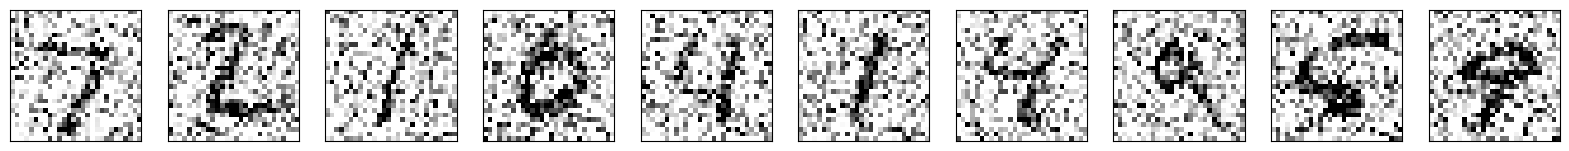

In [16]:
# Visulaize the noisy images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='binary')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [17]:
# Autoencoder Network
# ------------------------------------
input_layer = Input(shape=(28, 28, 1))

# Encoder
e = Conv2D(32, 3, activation="relu", padding="same")(input_layer)
e = AveragePooling2D(pool_size=(2,2), padding="same")(e)

e = Conv2D(16, 3, activation="relu", padding="same")(e)
encoded = AveragePooling2D(pool_size=(2,2), padding="same")(e)

# Decoder
d = Conv2D(16, 3, activation="relu", padding="same")(encoded)
d = UpSampling2D((2,2))(d)

d = Conv2D(32, 3, activation="relu", padding="same")(d)
d = UpSampling2D((2,2))(d)

output_layer = Conv2D(
    filters=1,
    kernel_size=3,
    activation="sigmoid",
    padding="same"
)(d)

autoencoder = Model(input_layer, output_layer)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mean_squared_error"
)

autoencoder.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 7, 7, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Model Training
# ------------------------------------
history = autoencoder.fit(
    train_input,
    x_train,
    validation_data=(test_input, x_test),
    epochs=8,
    batch_size=256,
    verbose=1
)

Epoch 1/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 97s 405ms/step - loss: 0.1178 - val_loss: 0.1140
Epoch 2/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 411ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 97s 411ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 97s 412ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 100s 423ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 97s 413ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 99s 423ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 140s 413ms/step - loss: 0.1120 - val_loss: 0.1140


In [19]:
# Denoise Images
# ------------------------------------
prediction = autoencoder.predict(test_input)


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


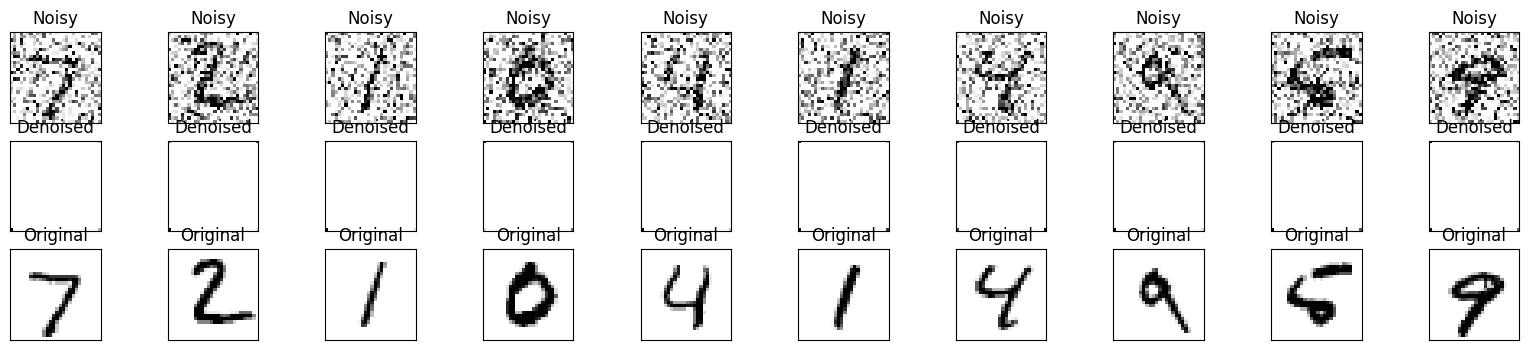

In [20]:
# Generate denoised outputs on the test set
denoised_images = autoencoder.predict(x_test_noisy)

# Result Visualization: Original, noisy and reconstructed images
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # original (Noisy)
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='binary')
    plt.title("Noisy")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed (Denoised)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='binary')
    plt.title("Denoised")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Clean (Original Ground Truth)
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='binary')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()